# Méthode de la Bissection

La méthode de bissection est une méthode de recherche de racine.
Elle repose sur le théorème des valeurs intermédiaires :
si f(a) et f(b) sont de signes opposés, alors il existe une racine dans [a, b].

À chaque itération, on coupe l'intervalle en deux et on garde
la moitié qui contient la racine.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def bissection (f, a, b, tol=1e-6):
    historique = []
    while (b - a) / 2 > tol:  # on continue tant que l'intervalle est trop grand
        m = (a + b) / 2
        historique.append((a,b,m))# on sauvegarde à chaque étape
        if f(a) * f(m) < 0:
            b = m
        else:
            a = m
    return (a + b) / 2, historique

In [8]:
f = lambda x: x**3 - 2

racine, historique = bissection(f, 1, 2)
print(f"Racine trouvée : {racine:.6f}")
print(f"Valeur exacte  : {2**(1/3):.6f}")
print(f"Nombre d'itérations : {len(historique)}")

Racine trouvée : 1.259921
Valeur exacte  : 1.259921
Nombre d'itérations : 19


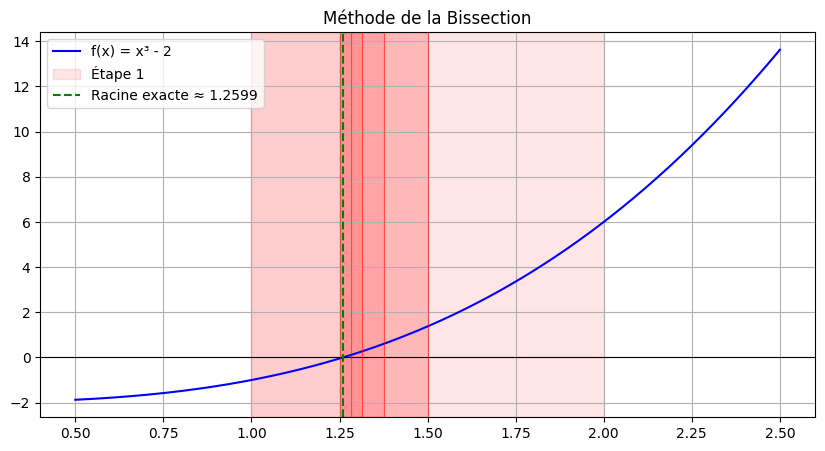

In [9]:
f = lambda x: x**3 - 2

x = np.linspace(0.5, 2.5, 500)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x, f(x), 'b-', label='f(x) = x³ - 2')
ax.axhline(0, color='black', linewidth=0.8)

# On affiche les 5 premières étapes pour pas surcharger
for i, (a, b, m) in enumerate(historique[:5]):
    ax.axvspan(a, b, alpha=0.1, color='red', label=f'Étape {i+1}' if i == 0 else '')
    ax.axvline(m, color='red', linewidth=0.8, alpha=0.5)
    
ax.axvline(2**(1/3), color='green', linestyle='--', label=f'Racine exacte ≈ {2**(1/3):.4f}')
ax.set_title('Méthode de la Bissection')
ax.legend()
ax.grid(True)

plt.show()

# Méthode de Newton-Raphson
Au lieu de travailler avec un intervalle, on pars d'un point de départ x₀ et on cherches à s'approcher de la racine de plus en plus vite.
La question que Newton se pose à chaque étape :

"Si je suis au point x, où est-ce que la tangente à la courbe coupe l'axe des x ?"

Ce point d'intersection devient notre prochain x.

In [24]:
def newton (f, df, x_0, tol=1e-6):
    x_sv = x_0 - f(x_0)/df(x_0)
    historique = []
    while abs(x_sv - x_0) > tol:
        historique.append(x_0)
        x_0 = x_sv
        x_sv = x_0 - f(x_0)/df(x_0)
    return x_sv, historique

In [25]:
f  = lambda x: x**3 - 2
df = lambda x: 3*x**2

racine, historique = newton(f, df, x_0=2)
print(f"Racine trouvée : {racine:.6f}")
print(f"Valeur exacte  : {2**(1/3):.6f}")
print(f"Nombre d'itérations : {len(historique)}")

Racine trouvée : 1.259921
Valeur exacte  : 1.259921
Nombre d'itérations : 4


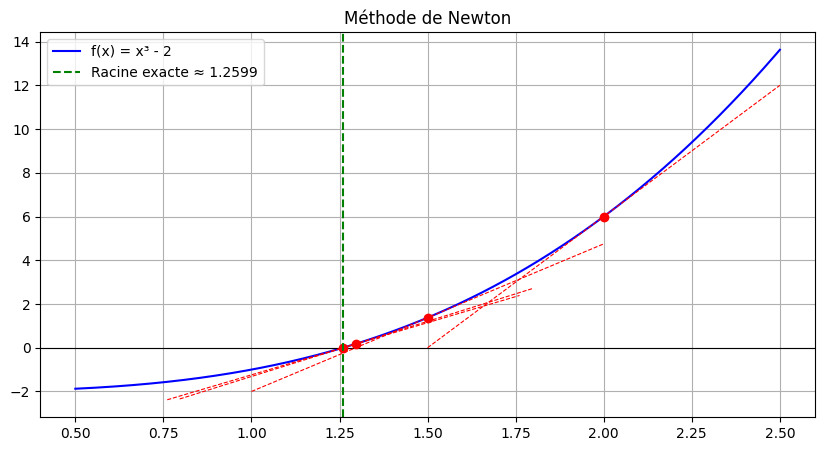

In [26]:
f  = lambda x: x**3 - 2
df = lambda x: 3*x**2

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x, f(x), 'b-', label='f(x) = x³ - 2')
ax.axhline(0, color='black', linewidth=0.8)
for x0 in historique:
    t = np.linspace(x0 - 0.5, x0 + 0.5, 100)
    tangente = f(x0) + df(x0) * (t - x0)
    ax.plot(x0, f(x0), 'ro', markersize=6)  # point sur la courbe
    ax.plot(t, tangente, 'r--', linewidth=0.8)  # tangente
ax.axvline(2**(1/3), color='green', linestyle='--', label=f'Racine exacte ≈ {2**(1/3):.4f}')
ax.set_title('Méthode de Newton')
ax.legend()
ax.grid(True)

plt.show()